In [1]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load California Housing Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['HouseValue'] = housing.target

# Display first 5 rows
print(df.head())

# Step 3: Select ONE feature (Simple Linear Regression)
X = df[['MedInc']]      # Independent variable
y = df['HouseValue']    # Dependent variable

# Step 4: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 5: Create the model
model = LinearRegression()

# Step 6: Train the model
model.fit(X_train, y_train)

# Step 7: Predict
y_pred = model.predict(X_test)

# Step 8: Print equation
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

print("\nRegression Equation")
print(f"HouseValue = {model.intercept_:.4f} + ({model.coef_[0]:.4f}) × MedInc")

# Step 9: Evaluate the model
print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseValue  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  
Intercept: 0.4445972916907881
Slope: 0.41933849393812705

Regression Equation
HouseValue = 0.4446 + (0.4193) × MedInc

Mean Squared Error: 0.7091157771765548
R2 Score: 0.45885918903846656


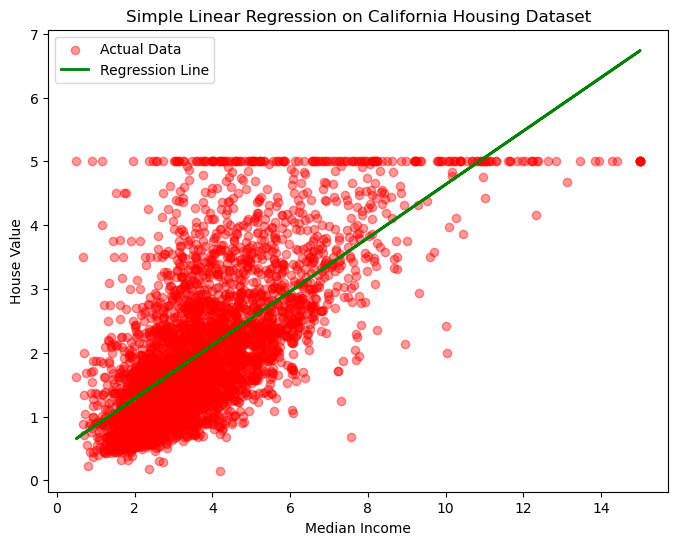

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='red', alpha=0.4, label='Actual Data')
plt.plot(X_test, y_pred, color='green', linewidth=2, label='Regression Line')

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression on California Housing Dataset")

plt.legend()
plt.show()